In [2]:
import pandas as pd

df = pd.read_csv("data/test_chatbot_intents.csv")
print("Original size:", len(df))
df.head()

Original size: 50


,utterance,intent
0,Hi,greeting
1,Hello there,greeting
2,Good evening,greeting
3,Hey!,greeting
4,Greetings,greeting


In [3]:
import random

prefixes = [
    "", "can you", "please", "i want to know",
    "could you", "tell me", "help me"
]

suffixes = [
    "", "please", "in simple words", "quickly",
    "briefly"
]

# optional word replacements
synonyms = {
    "what is": ["define", "explain", "tell me about"],
    "ai": ["artificial intelligence"],
    "nlp": ["natural language processing"],
    "tokenization": ["token splitting"],
}

In [5]:
def augment_text(text):
    text = text.lower()

    # synonym replacement
    for key, values in synonyms.items():
        if key in text:
            text = text.replace(key, random.choice(values))

    # prefix + suffix
    new_text = f"{random.choice(prefixes)} {text} {random.choice(suffixes)}"

    return " ".join(new_text.split())

In [8]:
TARGET_SIZE = 3000

augmented_data = []

intents = df["intent"].unique()

# group by intent (for balance)
grouped = {intent: df[df["intent"] == intent] for intent in intents}

while len(augmented_data) < TARGET_SIZE:
    for intent in intents:
        if len(augmented_data) >= TARGET_SIZE:
            break
        
        sample_row = grouped[intent].sample(1).iloc[0]
        new_text = augment_text(sample_row["utterance"])

        augmented_data.append({
            "utterance": new_text,
            "intent": intent
        })

new_df = pd.DataFrame(augmented_data)

print("Final size:", len(new_df))

Final size: 3000


In [9]:
new_df = new_df.sample(frac=1).reset_index(drop=True)

new_df.to_csv("augmented_dataset_N.csv", index=False)

print("Saved as augmented_dataset_N.csv")

Saved as augmented_dataset_N.csv


In [11]:
duplicates = df.duplicated(subset=["utterance"]).sum()
print("Duplicate text rows:", duplicates)

Duplicate text rows: 0


In [12]:
df_new = pd.read_csv("data/augmented_dataset_N.csv")

In [13]:
df_new.head()

,utterance,intent
0,i want to know stemming,stemming
1,tell me artificial intelligence in finance bri...,ai_applications
2,tell me natural language processing meaning br...,nlp_definition
3,can you good evening please,greeting
4,help me quit briefly,goodbye


In [14]:
duplicates = df.duplicated(subset=["utterance"]).sum()
print("Duplicate text rows:", duplicates)

Duplicate text rows: 0


In [15]:
df_new.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   utterance  3000 non-null   object
 1   intent     3000 non-null   object
dtypes: object(2)
memory usage: 47.0+ KB


In [17]:
diversity = df_new.groupby("intent")["utterance"].nunique()
total = df_new.groupby("intent")["utterance"].count()

div_df = pd.DataFrame({
    "total": total,
    "unique": diversity,
    "diversity_ratio": diversity / total
})

div_df

,total,unique,diversity_ratio
intent,,,
ai_applications,428,261,0.609813
goodbye,428,239,0.558411
greeting,429,201,0.468531
lemmatization,428,222,0.518692
nlp_definition,429,171,0.398601
stemming,429,189,0.440559
tokenization,429,201,0.468531


In [19]:
import pandas as pd

df = pd.read_csv("data/augmented_dataset_N.csv")  # or your file
print("Dataset size:", len(df))
df.head()

Dataset size: 3000


,utterance,intent
0,i want to know stemming,stemming
1,tell me artificial intelligence in finance bri...,ai_applications
2,tell me natural language processing meaning br...,nlp_definition
3,can you good evening please,greeting
4,help me quit briefly,goodbye


In [21]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["utterance"].apply(clean_text)

In [22]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["intent"]
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 2400
Test: 600


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_df["clean"])
X_test = vectorizer.transform(test_df["clean"])

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, train_df["intent"])

print("Model trained ")

Model trained 


In [25]:
from sklearn.metrics import accuracy_score, classification_report

preds = model.predict(X_test)

accuracy = accuracy_score(test_df["intent"], preds)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(test_df["intent"], preds))

Accuracy: 1.0

Classification Report:

                 precision    recall  f1-score   support

ai_applications       1.00      1.00      1.00        85
        goodbye       1.00      1.00      1.00        85
       greeting       1.00      1.00      1.00        86
  lemmatization       1.00      1.00      1.00        86
 nlp_definition       1.00      1.00      1.00        86
       stemming       1.00      1.00      1.00        86
   tokenization       1.00      1.00      1.00        86

       accuracy                           1.00       600
      macro avg       1.00      1.00      1.00       600
   weighted avg       1.00      1.00      1.00       600



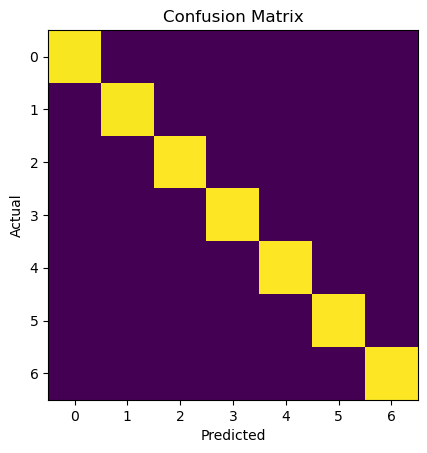

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df["intent"], preds)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
import joblib
from pathlib import Path

MODEL_PATH = Path("models/chatbot_model.pkl")
MODEL_PATH.parent.mkdir(exist_ok=True)

joblib.dump({
    "vectorizer": vectorizer,
    "model": model
}, MODEL_PATH)

print("Model saved at:", MODEL_PATH)

Model saved at: models/chatbot_model.pkl


In [46]:
data = joblib.load("models/chatbot_model.pkl")

vectorizer = data["vectorizer"]
model = data["model"]

In [60]:
def clean_text(text):
    text = str(text).lower()

    text = text.replace("nlp", "natural language processing")
    text = text.replace("ai", "artificial intelligence")

    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [61]:
def predict_intent(text):
    text_clean = clean_text(text)
    vec = vectorizer.transform([text_clean])
    return model.predict(vec)[0]

In [64]:
def predict_intent(text):
    text_clean = clean_text(text)
    vec = vectorizer.transform([text_clean])

    probs = model.predict_proba(vec)[0]
    idx = probs.argmax()

    intent = model.classes_[idx]
    confidence = probs[idx]
    print(confidence)
    if confidence < 0.4:
        return "fallback"

    return intent

In [67]:
# Test
print(predict_intent(" waht is the use of nlp?"))
print(predict_intent("bye"))

0.9823099332278641
nlp_definition
0.9609062702361542
goodbye


In [68]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
accuracy = accuracy_score(test_df["intent"], preds)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [69]:
from sklearn.metrics import classification_report

print(classification_report(test_df["intent"], preds))

                 precision    recall  f1-score   support

ai_applications       1.00      1.00      1.00        85
        goodbye       1.00      1.00      1.00        85
       greeting       1.00      1.00      1.00        86
  lemmatization       1.00      1.00      1.00        86
 nlp_definition       1.00      1.00      1.00        86
       stemming       1.00      1.00      1.00        86
   tokenization       1.00      1.00      1.00        86

       accuracy                           1.00       600
      macro avg       1.00      1.00      1.00       600
   weighted avg       1.00      1.00      1.00       600



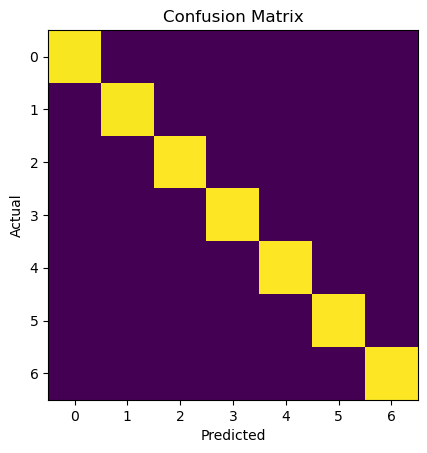

In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df["intent"], preds)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
import pandas as pd

results_df = pd.DataFrame({
    "true": test_df["intent"],
    "pred": preds
})

class_acc = results_df.groupby("true").apply(
    lambda x: (x["true"] == x["pred"]).mean()
)

print(class_acc)

true
ai_applications    1.0
goodbye            1.0
greeting           1.0
lemmatization      1.0
nlp_definition     1.0
stemming           1.0
tokenization       1.0
dtype: float64


/tmp/ipykernel_99401/840679609.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  class_acc = results_df.groupby("true").apply(


In [72]:
probs = model.predict_proba(X_test)

results_df["confidence"] = probs.max(axis=1)

print("Average confidence:", results_df["confidence"].mean())

Average confidence: 0.9047269915292422


In [73]:
wrong = results_df[results_df["true"] != results_df["pred"]]

print("Total wrong:", len(wrong))

wrong.head()

Total wrong: 0


,true,pred,confidence


In [74]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, vectorizer.transform(df["clean"]), df["intent"], cv=5)

print("CV Accuracy:", scores.mean())

CV Accuracy: 1.0


In [75]:
from sklearn.preprocessing import label_binarize

classes = model.classes_

y_test_bin = label_binarize(test_df["intent"], classes=classes)

In [76]:
y_probs = model.predict_proba(X_test)

In [77]:
from sklearn.metrics import roc_curve, auc

fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

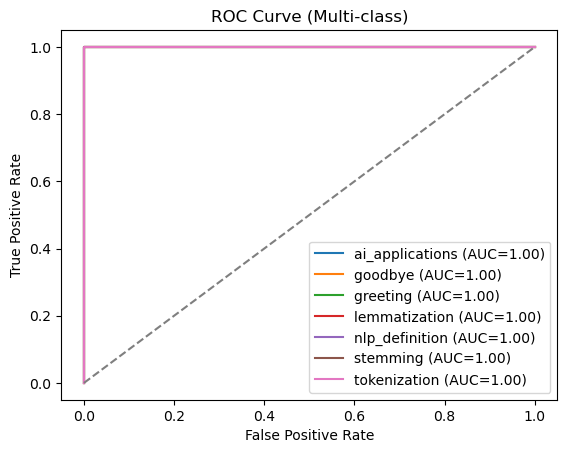

In [78]:
import matplotlib.pyplot as plt

plt.figure()

for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"{classes[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")

plt.legend()
plt.show()